
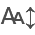

In [1]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import seaborn as sns
import matplotlib.pyplot as plt

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)



In [2]:
merged_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_merged')
processed_data_output_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

In [3]:
df = pd.read_csv(os.path.join(merged_data_input_path, 'merged_data.csv'))
df = df.rename(columns={
    'opponent_possesion': 'possesion_against',
    'opponent_passes_accuracy': 'passes_accuracy_against',
    'opponent_passes_total': 'passes_total_against',
    'opponent_passes_completed': 'passes_completed_against',
    'opponent_crosses': 'crosses_against',
    'opponent_touches': 'touches_against',
    'shots_allowed': 'shots_against',
    'shots_allowed_on_target': 'shots_on_target_against',
    'yellow_cards_opponent': 'yellow_cards_against',
    'red_cards_opponent': 'red_cards_against',
    'fouls_suffered': 'fouls_against',
    'fouls_committed': 'fouls'
})
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/London')
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


**FEATURE ENGINEERING**

In [5]:
def classify_points(row, suffix=''):
    if row[f'goals_scored{suffix}'] > row[f'goals_conceded{suffix}']:
        return 3
    elif row[f'goals_scored{suffix}'] < row[f'goals_conceded{suffix}']:
        return 0
    else:
        return 1

def classify_result(row, suffix=''):
    if row[f'goals_scored{suffix}'] > row[f'goals_conceded{suffix}']:
        if row['home_game'] == 1:
            return 'H'
        else:
            return 'A'
    elif row[f'goals_scored{suffix}'] < row[f'goals_conceded{suffix}']:
        if row['home_game'] == 1:
            return 'A'
        else:
            return 'H'
    else:
        return 'D'

In [6]:
# calculate differences, second half stats and points
df['xG_difference'] = df['xG'] - df['xGA']
df['goals_difference'] = df['goals_scored'] - df['goals_conceded']
df['shots_difference'] = df['shots'] - df['shots_against']
df['shots_on_target_difference'] = df['shots_on_target'] - df['shots_on_target_against']
df['possesion_difference'] = df['possesion'] - df['possesion_against']
df['passes_total_difference'] = df['passes_total'] - df['passes_total_against']
df['passes_completed_difference'] = df['passes_completed'] - df['passes_completed_against']
df['touches_difference'] = df['touches'] - df['touches_against']
df['crosses_difference'] = df['crosses'] - df['crosses_against']
df['corners_difference'] = df['corners'] - df['corners_against']
df['goals_scored_h2'] = df['goals_scored'] - df['goals_scored_h1']
df['goals_conceded_h2'] = df['goals_conceded'] - df['goals_conceded_h1']
df['result_h2'] = df.apply(lambda row: classify_result(row, '_h2'), axis=1)
df['points'] = df.apply(lambda row: classify_points(row), axis=1)
df['points_h1'] = df.apply(lambda row: classify_points(row, '_h1'), axis=1)
df['points_h2'] = df.apply(lambda row: classify_points(row, '_h2'), axis=1)

# calculate days of rest
df['datetime'] = pd.to_datetime(df['datetime'])
df['last_game_date'] = df.groupby('team')['datetime'].apply(lambda x: x.dt.date.shift(1)).reset_index(level=0, drop=True)
df['last_game_date'] = df.apply(lambda row: row['comp_before_date'] if not pd.isna(row['comp_before_date']) else row['last_game_date'], axis=1)
df['days_of_rest'] = (pd.to_datetime(df['datetime'].dt.date) - pd.to_datetime(df['last_game_date'])).dt.days
# first gameweek of the season days_of_rest valeus need to replaced by median to avoid NaNs and outliers
rest_median = df['days_of_rest'].median()
df.loc[df['gameweek'] == 1, 'days_of_rest'] = df.loc[df['gameweek'] == 1, :].apply(lambda row: row['days_of_rest'] if not pd.isna(row['comp_before_date']) else rest_median, axis=1)

# add feature new manager - first 5 league games after new coach hiring - new manager bounce effect
df_manager = deepcopy(df[['gameweek', 'team', 'manager']])
df_manager['1_game_back_manager'] = df_manager.groupby('team')['manager'].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)

# if new manager is hired with the start of new season, new manager bounce effect is eliminated
df_manager.loc[df_manager['gameweek'] == 1, '1_game_back_manager']  = df_manager.loc[df_manager['gameweek'] == 1, 'manager']
df_manager['2_games_back_manager'] = df_manager.groupby('team')['1_game_back_manager'].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)
df_manager.loc[df_manager['gameweek'] == 1, '2_games_back_manager']  = df_manager.loc[df_manager['gameweek'] == 1, 'manager']
df_manager['3_games_back_manager'] = df_manager.groupby('team')['2_games_back_manager'].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)
df_manager.loc[df_manager['gameweek'] == 1, '3_games_back_manager']  = df_manager.loc[df_manager['gameweek'] == 1, 'manager']
df_manager['4_games_back_manager'] = df_manager.groupby('team')['3_games_back_manager'].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)
df_manager.loc[df_manager['gameweek'] == 1, '4_games_back_manager']  = df_manager.loc[df_manager['gameweek'] == 1, 'manager']
df_manager['5_games_back_manager'] = df_manager.groupby('team')['4_games_back_manager'].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)
df_manager.loc[df_manager['gameweek'] == 1, '5_games_back_manager']  = df_manager.loc[df_manager['gameweek'] == 1, 'manager']

manager_cols = ['manager', '1_game_back_manager', '2_games_back_manager', 
                '3_games_back_manager', '4_games_back_manager', '5_games_back_manager']

df['is_new_manager'] = df_manager[manager_cols].apply(lambda row: int(pd.Series(row).unique().shape[0] > 1), axis=1)

# calculate win and draw probabilities for the team
df['win_probability'] = df.apply(
    lambda row: 1/row['win_odds']/(1/row['win_odds'] + 1/row['draw_odds'] + 1/row['loss_odds']),
    axis=1
)
df['draw_probability'] = df.apply(
    lambda row: 1/row['draw_odds']/(1/row['win_odds'] + 1/row['draw_odds'] + 1/row['loss_odds']),
    axis=1
)

df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [7]:
df.columns

Index(['season', 'gameweek', 'dayofweek', 'datetime', 'team', 'opponent',
       'home_game', 'xG', 'xGA', 'possesion', 'possesion_against',
       'passes_accuracy', 'passes_accuracy_against', 'passes_total',
       'passes_completed', 'passes_total_against', 'passes_completed_against',
       'crosses', 'crosses_against', 'touches', 'touches_against', 'idx',
       'comp_before', 'comp_before_name', 'comp_before_date', 'comp_after',
       'comp_after_name', 'comp_after_date', 'manager', 'referee',
       'goals_scored', 'goals_conceded', 'result', 'goals_scored_h1',
       'goals_conceded_h1', 'result_h1', 'shots', 'shots_against',
       'shots_on_target', 'shots_on_target_against', 'corners',
       'corners_against', 'fouls', 'fouls_against', 'yellow_cards',
       'yellow_cards_against', 'red_cards', 'red_cards_against', 'win_odds',
       'draw_odds', 'loss_odds', 'over_2_5_goals_odds', 'under_2_5_goals_odds',
       'datetime_weather', 'temperature_2m', 'apparent_temperature',

In [8]:
all_stats_cols_list = [
    'xG','xGA','xG_difference',
    
    'shots','shots_against', 'shots_difference',
    'shots_on_target','shots_on_target_against',
    'shots_on_target_difference',
    
    'passes_completed','passes_completed_against',
    'passes_completed_difference',
    'passes_total','passes_total_against',
    'passes_total_difference', 
    'crosses', 'crosses_against', 'crosses_difference',
    'touches','touches_against', 'touches_difference',
     
    'possesion','possesion_against','possesion_difference',
    
    'goals_scored','goals_conceded','goals_difference',
    
    'corners','corners_against', 'corners_difference',
    
    'fouls', 'fouls_against', 'yellow_cards',
    'yellow_cards_against', 'red_cards', 'red_cards_against',
    
    'goals_scored', 'goals_conceded', 'goals_scored_h1',
    'goals_conceded_h1', 'goals_scored_h2', 'goals_conceded_h2',
    
    'temperature_2m', 'apparent_temperature',
    'precipitation', 'rain', 'snowfall', 'surface_pressure',
    'wind_speed_10m', 'relative_humidity_2m', 'wind_gusts_10m',
    'cloud_cover', 'et0_fao_evapotranspiration',

    'points', 'points_h1', 'points_h2',
       
    'days_of_rest', 'is_new_manager',
    
    'win_probability', 'draw_probability'
]

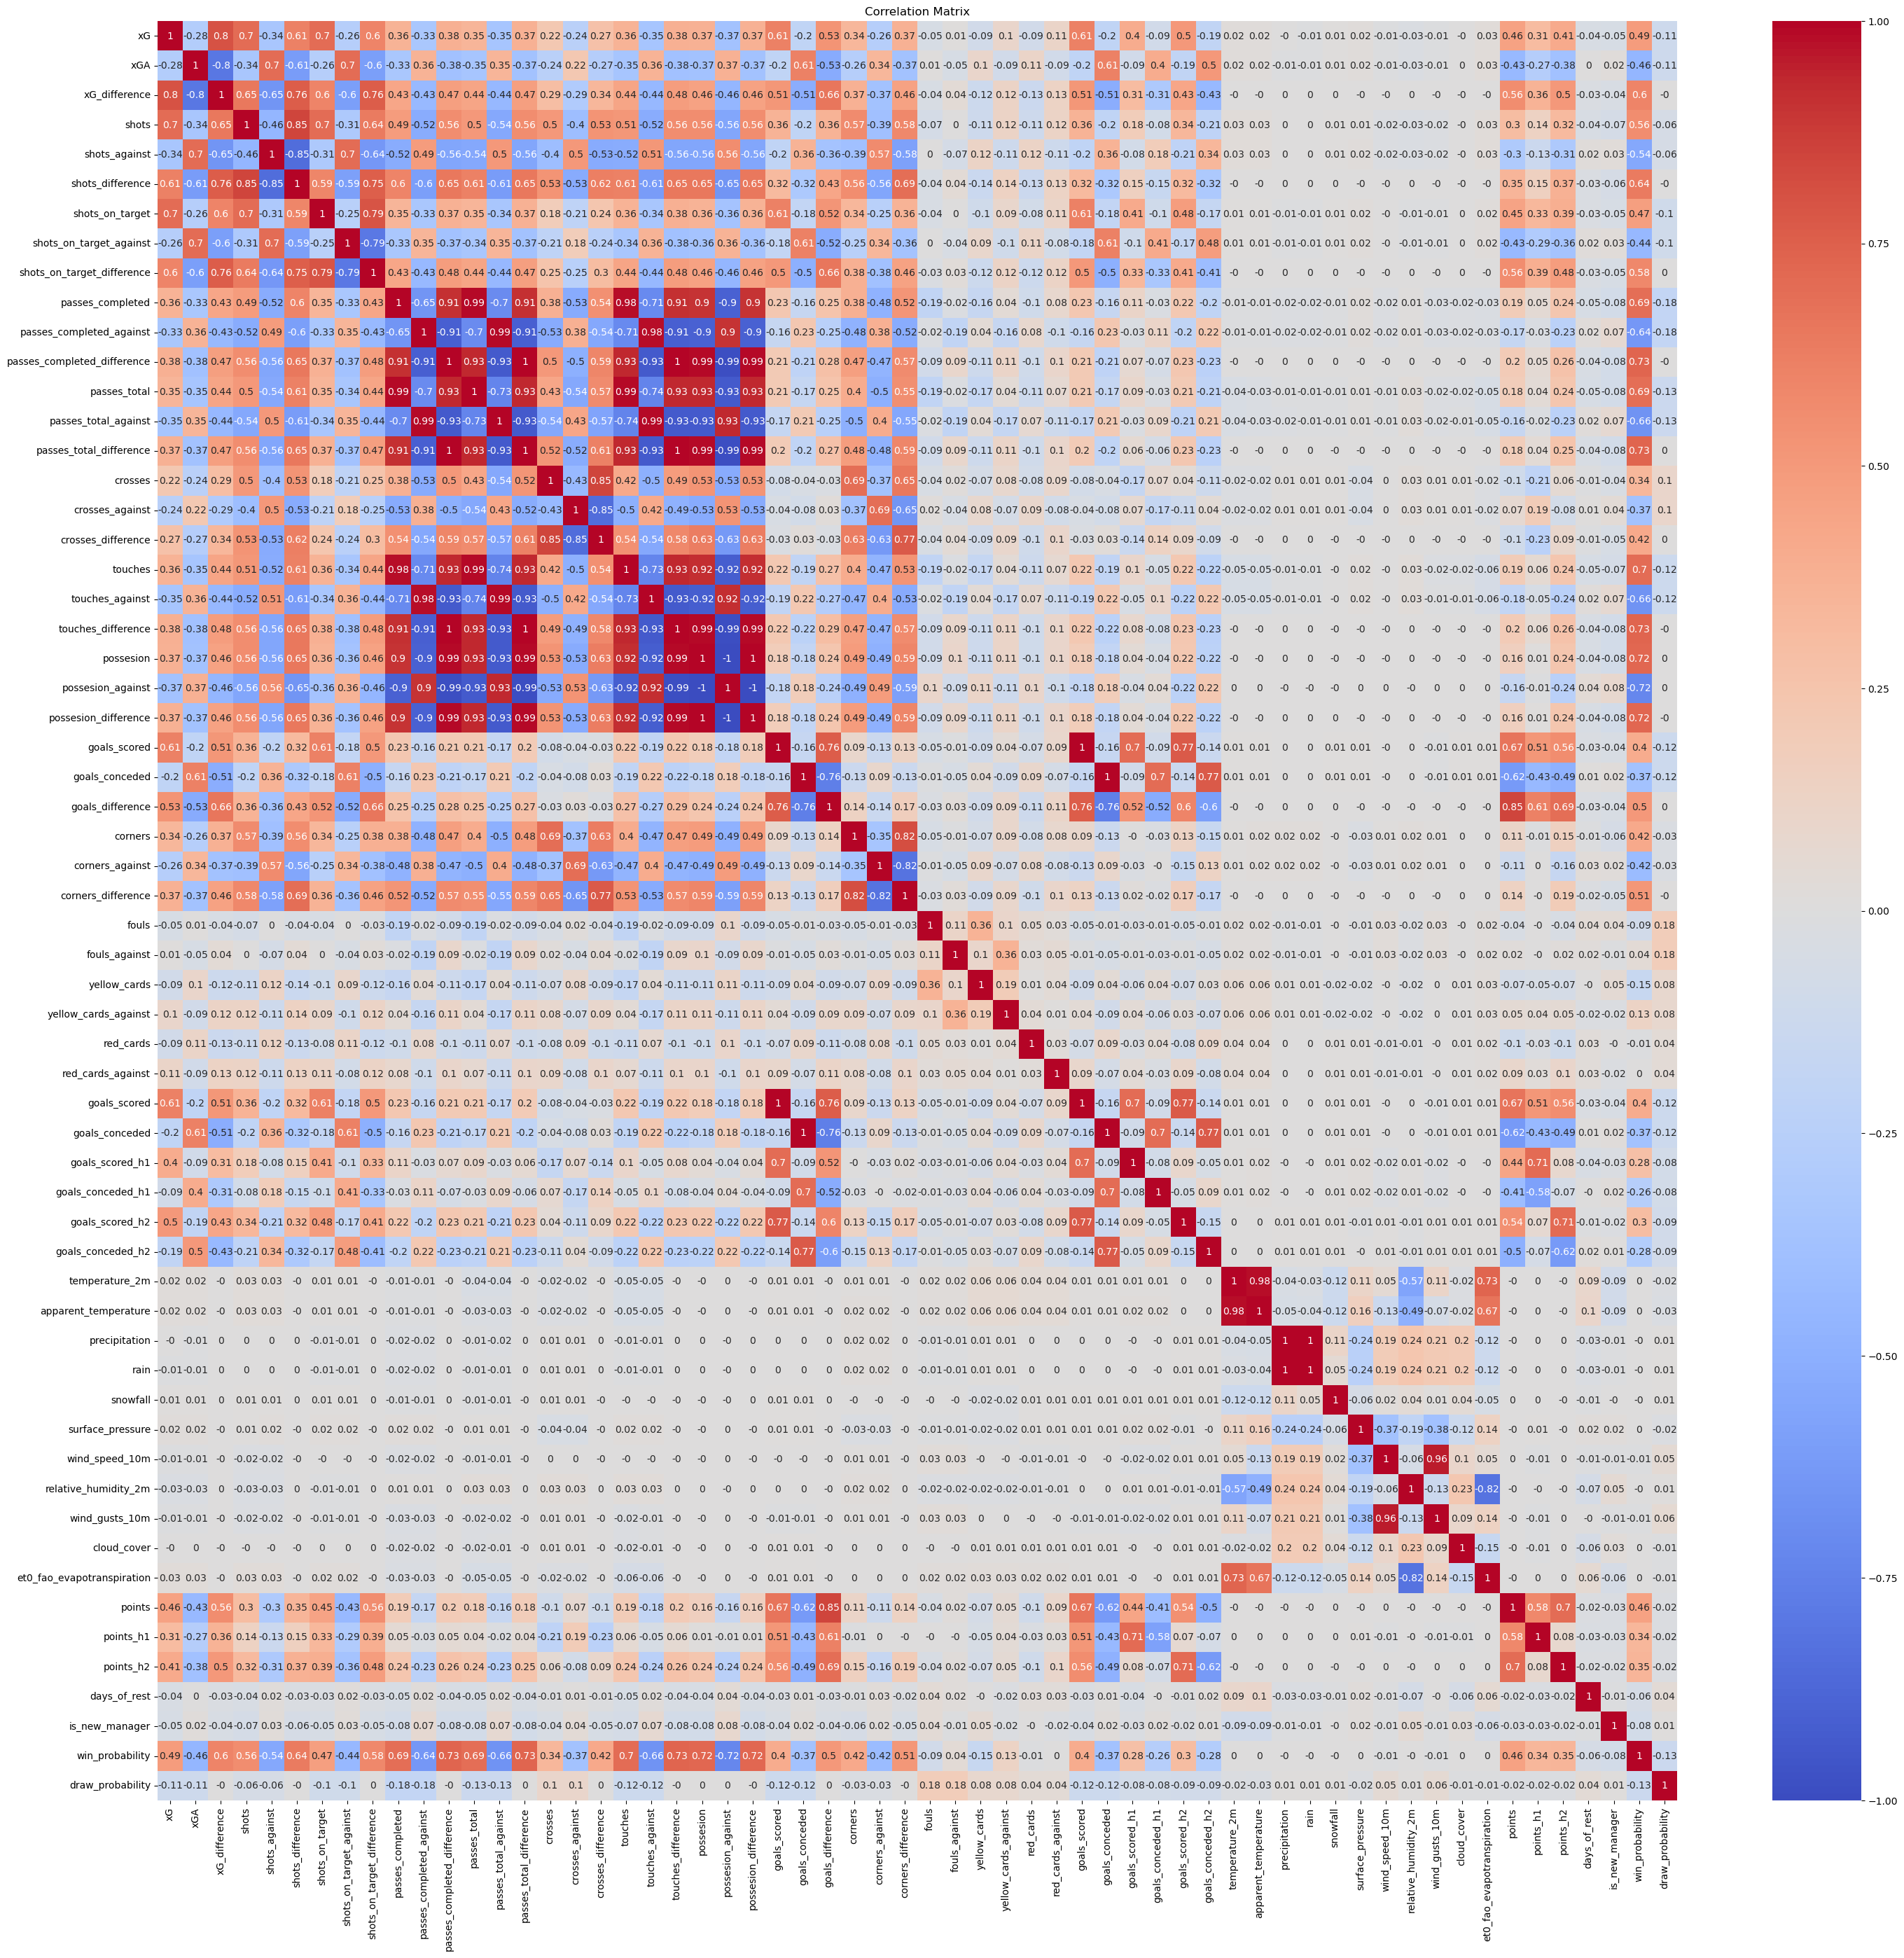

In [9]:
# Compute correlation matrix
corr = df[all_stats_cols_list].corr().round(2)

# Plot heatmap
plt.figure(figsize=(35, 33))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.savefig(os.path.join(figures_path, 'correlation_matrix.png'))
plt.show()


Rolling features creation

In [10]:
# rolling features list
rolling_stats_list = [
    'xG','xGA','xG_difference',
    
    'shots','shots_against', 'shots_difference',
    'shots_on_target','shots_on_target_against',
    'shots_on_target_difference',
    
    'passes_completed','passes_completed_against',
    'passes_completed_difference',
    'passes_total','passes_total_against',
    'passes_total_difference', 
    'crosses', 'crosses_against', 'crosses_difference',
    'touches','touches_against', 'touches_difference',
     
    'possesion','possesion_against','possesion_difference',
    
    'goals_scored','goals_conceded','goals_difference',
    
    'corners','corners_against', 'corners_difference',
    
    'fouls', 'fouls_against', 'yellow_cards',
    'yellow_cards_against', 'red_cards', 'red_cards_against',
    
    'goals_scored', 'goals_conceded', 'goals_scored_h1',
    'goals_conceded_h1', 'goals_scored_h2', 'goals_conceded_h2',

    'points', 'points_h1', 'points_h2',
       
]
new_columns = {}
for col in rolling_stats_list:
    new_columns[f"avg_7_{col}"] = df.groupby('team')[col].apply(lambda x: x.shift(1).rolling(7, min_periods=1).mean()).reset_index(level=0, drop=True)
    new_columns[f"avg_3_{col}"] = df.groupby('team')[col].apply(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).reset_index(level=0, drop=True)
    new_columns[f"last_1_{col}"] = df.groupby('team')[col].apply(lambda x: x.shift(1)).reset_index(level=0, drop=True)
    new_columns[f"avg_5_h/a_{col}"] = df.groupby(['home_game','team'])[col].apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).reset_index(level=(0,1), drop=True)

if f"avg_5_h/a_{col}" not in df.columns:
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)
    
# handle missing values for h/a columns - those columns have NaN values in first home and away game of each team
# NaN values are filled by stat value from first game (despite it was played in opposite location)
for col in rolling_stats_list:
    df.loc[df[f"avg_5_h/a_{col}"].isna() & ~df[f"last_1_{col}"].isna(), f"avg_5_h/a_{col}"] = df.loc[df[f"avg_5_h/a_{col}"].isna() & ~df[f"last_1_{col}"].isna(), f"last_1_{col}"]


df[(df['team'] == 'Luton')][['team', 'opponent', 'home_game', 'goals_scored', 'avg_7_goals_scored', 'last_1_goals_scored', 'avg_5_h/a_goals_scored']]


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [11]:
# count cumulative points and goals difference to calculate position in the league table
# all cumulative stats are shifted to get the stats before the game
df = df.sort_values(['team', 'season', 'gameweek'])

df['season_points'] = df.groupby(['team', 'season'])['points'].cumsum().shift(fill_value=0)
df['season_goals_scored'] = df.groupby(['team', 'season'])['goals_scored'].cumsum().shift(fill_value=0)
df['season_goals_conceded'] = df.groupby(['team', 'season'])['goals_conceded'].cumsum().shift(fill_value=0)
df['season_goals_difference'] = df.groupby(['team', 'season'])['goals_difference'].cumsum().shift(fill_value=0)

df.loc[df['gameweek'] == 1, ['season_points', 'season_goals_scored', 'season_goals_difference', 'season_goals_conceded']] = 0

df = df.sort_values(['season', 'gameweek', 'season_points', 'season_goals_difference', 'season_goals_scored', 'avg_7_points'], ascending=[True, True, False, False, False, False])
df['league_position'] = df.groupby(['season', 'gameweek']).cumcount() + 1

df = df.sort_index()
df[(df['team'] == 'Chelsea') & (df['season'] == '2018/2019')][['gameweek', 'team', 'opponent', 'home_game', 'goals_scored', 'goals_conceded', 'points', 'avg_7_points', 'avg_5_h/a_points', 'league_position', 'season_points', 'season_goals_difference', 'season_goals_scored']]


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [12]:
# elo rating feature creation

# Miejsce w tabeli PL 2016/17
season_2016_17_ranks = {
    "Chelsea": 1, "Tottenham": 2, "Manchester City": 3, "Liverpool": 4, "Arsenal": 5,
    "Manchester United": 6, "Everton": 7, "Southampton": 8, "Bournemouth": 9, "West Brom": 10,
    "West Ham": 11, "Leicester": 12, "Stoke": 13, "Crystal Palace": 14, "Swansea": 15,
    "Burnley": 16, "Watford": 17
}

def map_position_to_elo(position, base=1650, step=15):
    return base - (position - 1) * step

# Słownik ELO startowych
initial_elos = {team: map_position_to_elo(pos) for team, pos in season_2016_17_ranks.items()}

print(initial_elos)

def calculate_elo_column(df, k_factor=40, initial_elos=initial_elos):
    elo_ratings = initial_elos
    elo_history = []
    
    default_elo = min(initial_elos.values()) - 20

    for idx, row in df.iterrows():
        # to calculate elo once per each game
        if idx % 2 == 1:
            continue
        team = row['team']
        opponent = row['opponent']
        g_scored = row['goals_scored']
        g_conceded = row['goals_conceded']

        r_team = elo_ratings.get(team, default_elo)
        r_opp = elo_ratings.get(opponent, default_elo)

        # Zapisz ELO przed meczem
        elo_history.append(r_team)
        elo_history.append(r_opp)

        # Oczekiwane wyniki
        expected_team = 1 / (1 + 10 ** ((r_opp - r_team) / 400))
        expected_opp = 1 - expected_team

        # Faktyczny wynik
        if g_scored > g_conceded:
            score_team, score_opp = 1, 0
        elif g_scored < g_conceded:
            score_team, score_opp = 0, 1
        else:
            score_team, score_opp = 0.5, 0.5

        # Aktualizacja rankingów
        elo_ratings[team] = r_team + k_factor * (score_team - expected_team)
        elo_ratings[opponent] = r_opp + k_factor * (score_opp - expected_opp)
        
        # remove relegated teams from elo_ratings dict
        next_row = df.loc[idx+1,:]
        if row['gameweek'] == 38:
            if row['league_position'] > 17:
                del elo_ratings[team]
            if next_row['league_position'] > 17:
                del elo_ratings[opponent]

    # Dodanie kolumny
    df['elo'] = elo_history
    return df
df = calculate_elo_column(df)
df.loc[(df['season'] == '2024/2025') & (df['team'] == 'Tottenham'), ['season', 'gameweek', 'team', 'opponent', 'goals_scored', 'goals_conceded', 'elo']]

{'Chelsea': 1650, 'Tottenham': 1635, 'Manchester City': 1620, 'Liverpool': 1605, 'Arsenal': 1590, 'Manchester United': 1575, 'Everton': 1560, 'Southampton': 1545, 'Bournemouth': 1530, 'West Brom': 1515, 'West Ham': 1500, 'Leicester': 1485, 'Stoke': 1470, 'Crystal Palace': 1455, 'Swansea': 1440, 'Burnley': 1425, 'Watford': 1410}


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [13]:
opponent_stats = ['team', 'idx']
prefixes_list = ["avg_7_", "avg_3_", "last_1_","avg_5_h/a_"]
opponent_stats += [
    f"{prefix}{col}" for prefix in prefixes_list 
    for col in rolling_stats_list
]
opponent_stats.extend([
    'season_points','season_goals_scored','season_goals_conceded','season_goals_difference',
    'league_position', 'days_of_rest', 'is_new_manager', 'elo'
])

opponent_stats
df_merged = pd.merge(df, df[opponent_stats], how='inner', left_on=['opponent', 'idx'], 
         right_on=['team', 'idx'], suffixes=('', '_opponent'))

df_merged['elo_diff'] = np.abs(df_merged['elo'] - df_merged['elo_opponent'])

df_merged[['team', 'opponent', 'elo', 'elo_opponent', 'elo_diff']]


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [14]:
df_merged.loc[(df_merged['season'] == '2024/2025') & (df_merged['gameweek'] == 14), ['team', 'opponent', 'elo', 'elo_opponent', 'elo_diff', 'win_probability', 'draw_probability']]

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [15]:
# creation of feature telling if the result was expected or not
df_merged['not_loss_probability'] = df_merged['win_probability'] + df_merged['draw_probability']

# classification is done based on quantiles
elo_diff_thr = df_merged['elo_diff'].quantile(0.7)
not_loss_prob_thr = df_merged['not_loss_probability'].quantile(0.2)
win_prob_thr = df_merged['win_probability'].quantile(0.8)


def prob_unexpected_result(row, not_loss_prob_thr, win_prob_thr):
    not_loss_prob = row['not_loss_probability']
    win_prob = row['win_probability']
    points = row['points']  

    if not_loss_prob < not_loss_prob_thr and points in [3,1]:
        return 1
    elif win_prob >= win_prob_thr and points != 3:
        return 1
    else:
        return 0

def elo_unexpected_result(row, elo_diff_thr):
    elo_diff = row['elo_diff']
    elo_team = row['elo']
    elo_opponent = row['elo_opponent']
    points = row['points']

    if elo_diff >= elo_diff_thr and elo_team > elo_opponent and points != 3:
        return 1
    elif elo_diff >= elo_diff_thr and elo_team < elo_opponent and points in [3, 1]:
        return 1
    else:
        return 0
    

df_merged['prob_unexpected_result'] = df_merged.apply(lambda row: prob_unexpected_result(row, not_loss_prob_thr, win_prob_thr), axis=1)
df_merged['elo_unexpected_result'] = df_merged.apply(lambda row: elo_unexpected_result(row, elo_diff_thr), axis=1)
df_merged.loc[(df_merged['elo_unexpected_result'] != df_merged['prob_unexpected_result']), ['season', 'gameweek', 'team', 'opponent', 'goals_scored', 'goals_conceded', 'result', 'points',
            'elo_diff', 'elo', 'elo_opponent', 
            'not_loss_probability', 'win_probability', 
            'prob_unexpected_result', 'elo_unexpected_result']]



Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [16]:
# Save the processed DataFrame to a CSV file
df_merged.to_csv(os.path.join(processed_data_output_path, 'features_added.csv'))